# Exploratory Data Analysis - EDA


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 

back to root to call functions from helpers.py file

In [2]:
import os
from pathlib import Path
print(Path.cwd())
os.chdir(Path('..').resolve())
from src.utils.helpers import apply_balance, plot_top_ngrams, save
print(Path.cwd())

/mnt/d/career/digilians/sentiment-analysis-of-amazon-reviews-using-machine-learning/notebooks
/mnt/d/career/digilians/sentiment-analysis-of-amazon-reviews-using-machine-learning


load train dataset

In [3]:
sample_train = pd.read_csv(r'data/samples/sample_train.csv', dtype=str, quoting=0)
sample_train.head()

,review_target,review_title,review_content
0,2,"Good tool, good price",I received the tool in a timely fashion.Assemb...
1,1,Not what I expected!,"This toy has alot of activities, but is not a ..."
2,1,Not so great,"I wanted this hair wax for a while, and once I..."
3,1,"Great hardware, but the PC software is terrible",The hardware functionality is excellent for ou...
4,2,A must for anyone who cooks and bakes!!!,To say that i am pleased with my kitchenaid ar...


In [4]:
sample_train.info()

<class 'pandas.DataFrame'>
RangeIndex: 80000 entries, 0 to 79999
Data columns (total 3 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   review_target   80000 non-null  str  
 1   review_title    79994 non-null  str  
 2   review_content  80000 non-null  str  
dtypes: str(3)
memory usage: 1.8 MB


Check Missing Values


In [5]:
sample_train.isna().sum()

review_target     0
review_title      6
review_content    0
dtype: int64

In [6]:
sample_train.dropna(inplace=True)
sample_train.isna().sum()

review_target     0
review_title      0
review_content    0
dtype: int64

check duplications

In [7]:
sample_train.duplicated().sum()

np.int64(0)

Check Class Balance

In [8]:
sample_train.value_counts('review_target')

review_target
1    40008
2    39986
Name: count, dtype: int64

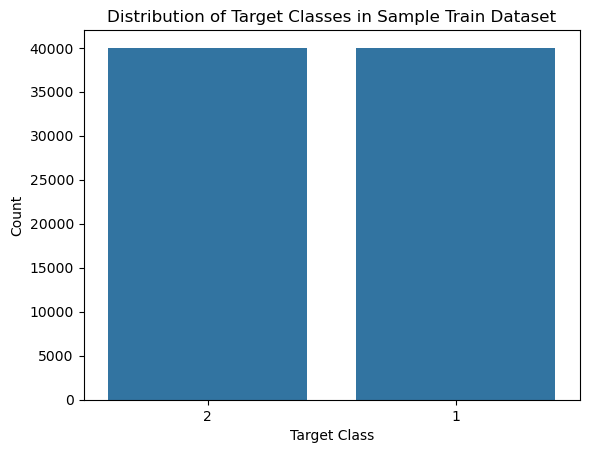

In [9]:
sns.countplot(x='review_target', data=sample_train)
plt.title('Distribution of Target Classes in Sample Train Dataset')
plt.xlabel('Target Class')
plt.ylabel('Count')
plt.show()

label distribution

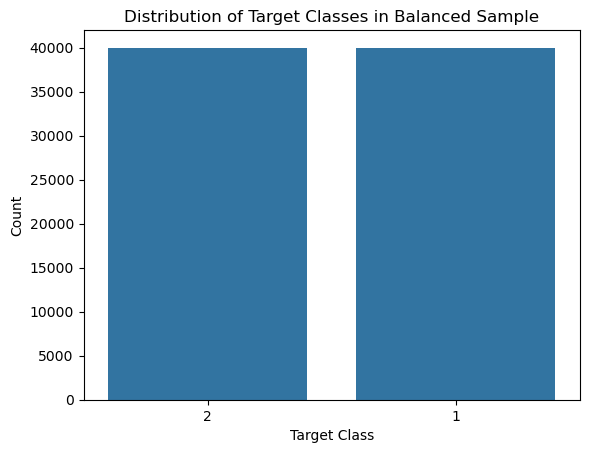

In [10]:
balanced_sample_train = apply_balance(sample_train, target_col='review_target', random_state=42)
sns.countplot(x='review_target', data=balanced_sample_train)
plt.title('Distribution of Target Classes in Balanced Sample')
plt.xlabel('Target Class')
plt.ylabel('Count')
plt.show()

In [11]:
balanced_sample_train.value_counts('review_target')

review_target
2    39986
1    39986
Name: count, dtype: int64

Text Analysis by char and word counts

In [12]:
balanced_sample_train['char_count'] = balanced_sample_train['review_content'].str.len()
balanced_sample_train.head()

,review_target,review_title,review_content,char_count
0,2,GREAT CAMRA,I HAVE HAD THE DX6340 FOR ABOUT A YEAR.I LOVE ...,586
1,1,not so great,I'm using this book in an introductory organic...,570
2,1,Inaccurate and disappointing,I only read the first few chapters and was bom...,214
3,1,Equus 3340,"Feels cheaply made, the battery contacts were ...",193
4,2,awesome sheets!,I love these sheets! They are sleek & smooth w...,198


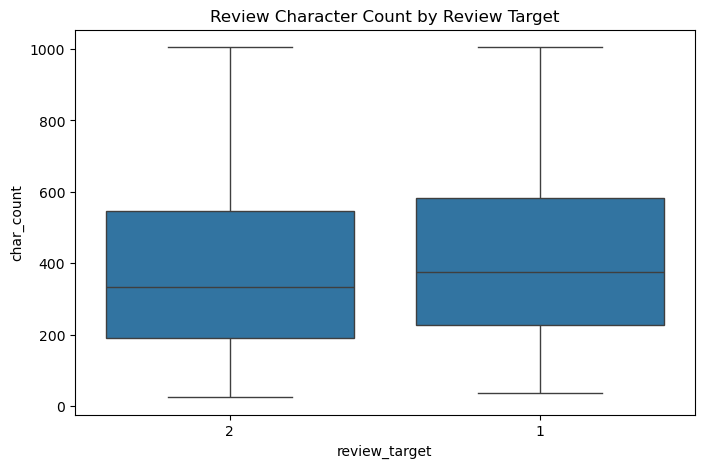

In [13]:
plt.figure(figsize=(8, 5))
sns.boxplot(x='review_target', y='char_count', data=balanced_sample_train)
plt.title('Review Character Count by Review Target')
plt.show()

In [14]:
balanced_sample_train['word_count'] = balanced_sample_train['review_content'].apply(lambda x: len(str(x).split()))
balanced_sample_train.head()

,review_target,review_title,review_content,char_count,word_count
0,2,GREAT CAMRA,I HAVE HAD THE DX6340 FOR ABOUT A YEAR.I LOVE ...,586,108
1,1,not so great,I'm using this book in an introductory organic...,570,88
2,1,Inaccurate and disappointing,I only read the first few chapters and was bom...,214,40
3,1,Equus 3340,"Feels cheaply made, the battery contacts were ...",193,34
4,2,awesome sheets!,I love these sheets! They are sleek & smooth w...,198,38


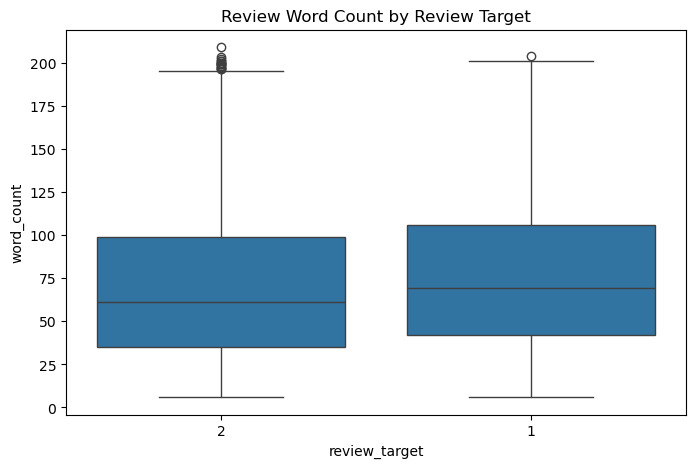

In [15]:
plt.figure(figsize=(8, 5))
sns.boxplot(x='review_target', y='word_count', data=balanced_sample_train)
plt.title('Review Word Count by Review Target')
plt.show()

apply describe on two numerical cols

In [16]:
balanced_sample_train[['char_count','word_count']].describe().T

,count,mean,std,min,25%,50%,75%,max
char_count,79972.0,404.347584,234.072075,25.0,207.0,354.0,564.0,1005.0
word_count,79972.0,74.022608,42.263353,6.0,38.0,65.0,103.0,209.0


In [17]:
print("Average characters per review:", balanced_sample_train['char_count'].mean())
print("Average words per review:", balanced_sample_train['word_count'].mean())

Average characters per review: 404.34758415445407
Average words per review: 74.02260791276947


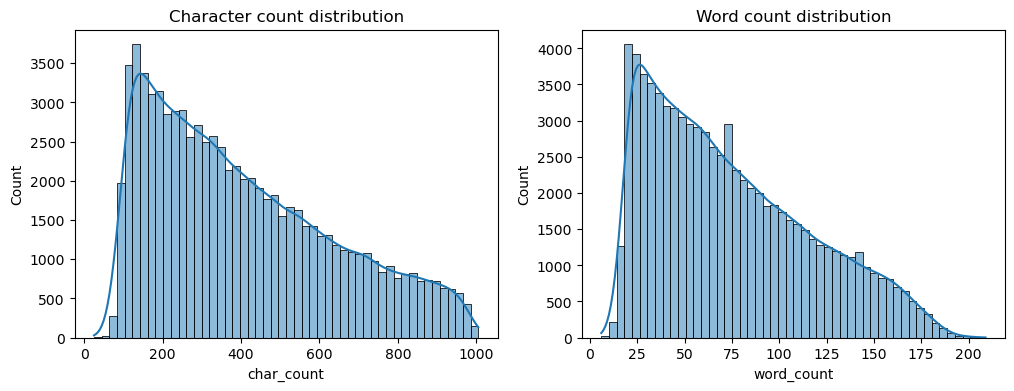

In [19]:
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
sns.histplot(balanced_sample_train['char_count'], bins=50, kde=True)
plt.title('Character count distribution')
plt.subplot(1,2,2)
sns.histplot(balanced_sample_train['word_count'], bins=50, kde=True)
plt.title('Word count distribution')
plt.show()

top unigrams, bigrams, and trigrams

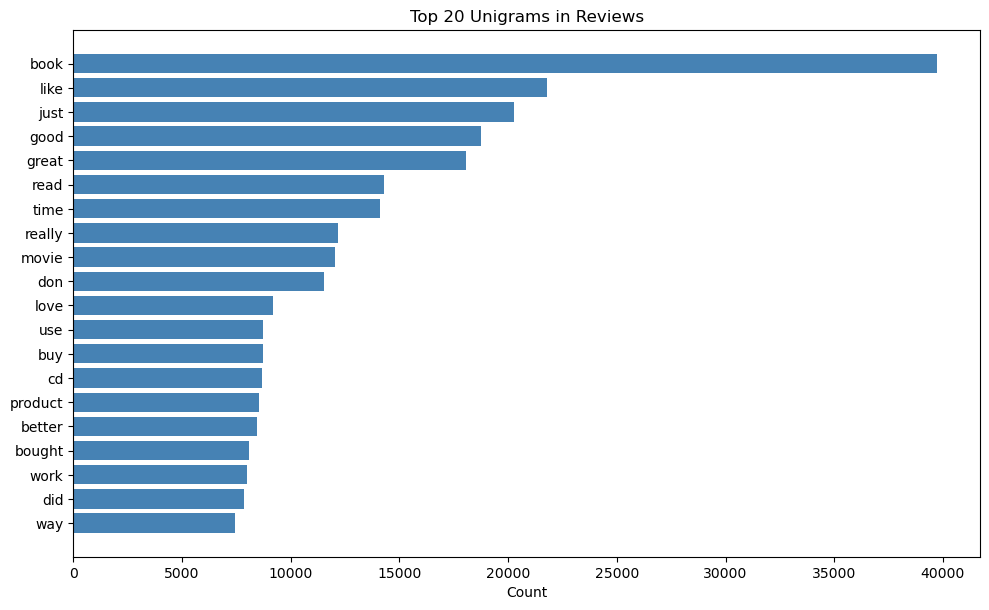

Top 20 Unigrams: [('book', np.int64(39719)), ('like', np.int64(21795)), ('just', np.int64(20285)), ('good', np.int64(18740)), ('great', np.int64(18062)), ('read', np.int64(14299)), ('time', np.int64(14103)), ('really', np.int64(12189)), ('movie', np.int64(12015)), ('don', np.int64(11520)), ('love', np.int64(9177)), ('use', np.int64(8714)), ('buy', np.int64(8713)), ('cd', np.int64(8679)), ('product', np.int64(8550)), ('better', np.int64(8430)), ('bought', np.int64(8095)), ('work', np.int64(7978)), ('did', np.int64(7837)), ('way', np.int64(7431))]


In [20]:
top_unigrams = plot_top_ngrams(balanced_sample_train['review_content'], n=1, top_k=20, stop_words='english', title='Top 20 Unigrams in Reviews')
print("Top 20 Unigrams:", top_unigrams)

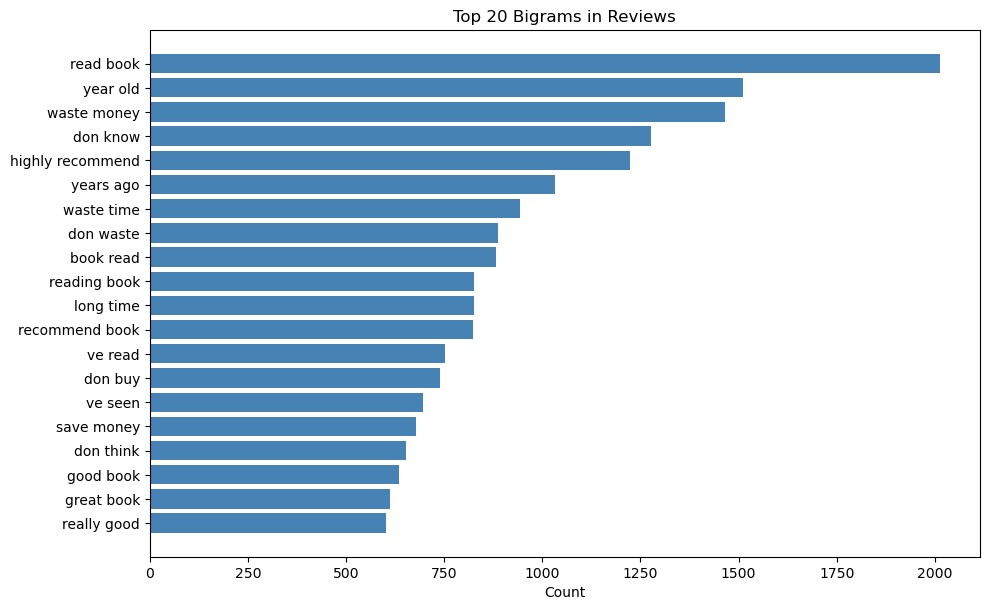

Top 20 Bigrams: [('read book', np.int64(2014)), ('year old', np.int64(1511)), ('waste money', np.int64(1466)), ('don know', np.int64(1277)), ('highly recommend', np.int64(1222)), ('years ago', np.int64(1032)), ('waste time', np.int64(943)), ('don waste', np.int64(887)), ('book read', np.int64(882)), ('reading book', np.int64(826)), ('long time', np.int64(825)), ('recommend book', np.int64(823)), ('ve read', np.int64(752)), ('don buy', np.int64(740)), ('ve seen', np.int64(697)), ('save money', np.int64(678)), ('don think', np.int64(653)), ('good book', np.int64(636)), ('great book', np.int64(611)), ('really good', np.int64(601))]


In [21]:
top_bigrams = plot_top_ngrams(balanced_sample_train['review_content'], n=2, top_k=20, stop_words='english', title='Top 20 Bigrams in Reviews')
print("Top 20 Bigrams:", top_bigrams)

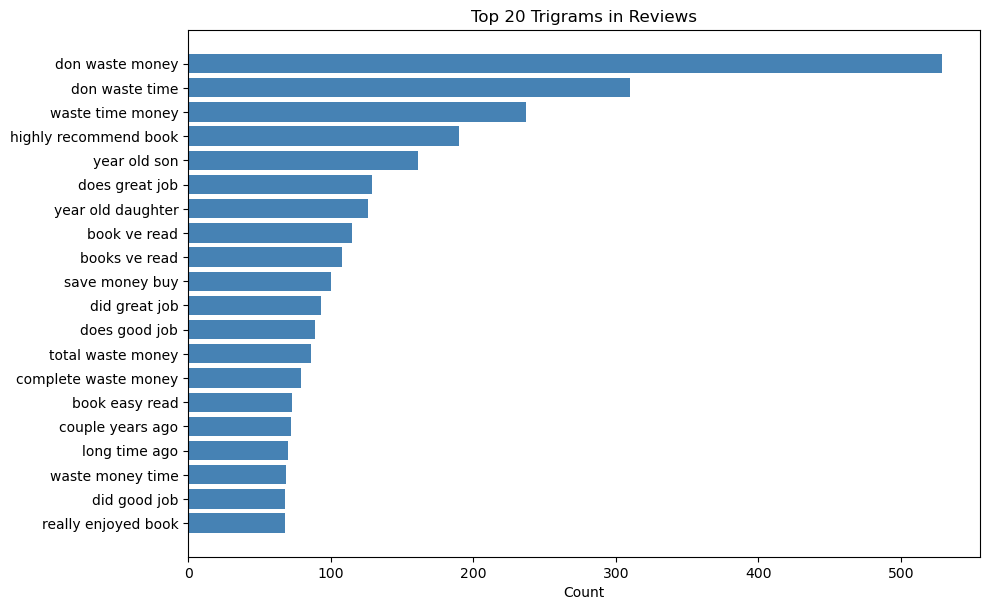

Top 20 Trigrams: [('don waste money', np.int64(529)), ('don waste time', np.int64(310)), ('waste time money', np.int64(237)), ('highly recommend book', np.int64(190)), ('year old son', np.int64(161)), ('does great job', np.int64(129)), ('year old daughter', np.int64(126)), ('book ve read', np.int64(115)), ('books ve read', np.int64(108)), ('save money buy', np.int64(100)), ('did great job', np.int64(93)), ('does good job', np.int64(89)), ('total waste money', np.int64(86)), ('complete waste money', np.int64(79)), ('book easy read', np.int64(73)), ('couple years ago', np.int64(72)), ('long time ago', np.int64(70)), ('waste money time', np.int64(69)), ('did good job', np.int64(68)), ('really enjoyed book', np.int64(68))]


In [22]:
top_trigrams = plot_top_ngrams(balanced_sample_train['review_content'], n=3, top_k=20, stop_words='english', title='Top 20 Trigrams in Reviews')
print("Top 20 Trigrams:", top_trigrams)

save balanced_sample_train dataset

In [23]:
save(base_path='data/balanced', df=balanced_sample_train, df_name='balanced_sample_train.csv')

Saved dataframe to data/balanced/balanced_sample_train.csv


{'csv': PosixPath('data/balanced/balanced_sample_train.csv')}